<a href="https://colab.research.google.com/github/vivilchesm-rgb/MineriaEvaluacion/blob/vicente-vilches/PeliculasPresupuestos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Importación y Carga de dataset

In [1]:
#Importamos las librerias necesarias para realizar los diversos analisis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Cargamos el dataset
df = pd.read_csv("/content/expensive_movie.csv")

In [3]:
#Revisamos la cantidad de filas y columnas del dataset
df.shape

(8121, 17)

In [4]:
#Visualizamos las primeras filas para obtener información de estas
df.head()

,ID,Title,Original_Language,Release_Date,Popularity,Vote_Average,Vote_Count,Runtime,Budget,Revenue,Status,Tagline,Overview,Genres,Production_Companies,Production_Countries,Spoken_Languages
0,969681,Spider-Man: Brand New Day,en,2026-07-29,81.5967,0.000,0,0,0,0,Post Production,A brand new day starts now.,Four years have passed since the events of No ...,"Science Fiction, Action, Adventure","Marvel Studios, Columbia Pictures, Pascal Pict...",United States of America,English
1,1242898,Predator: Badlands,en,2025-11-05,78.4384,7.704,2424,107,105000000,184500000,Released,First hunt. Last chance.,"Cast out from his clan, a young Predator finds...","Action, Science Fiction, Adventure","20th Century Studios, Lawrence Gordon Producti...",United States of America,"French, English"
2,11375,Hollywood Homicide,en,2003-06-09,62.2209,5.238,686,116,75000000,51142659,Released,They're two cops with one shot at solving a mu...,"Joe Gavilan and his new partner K. C. Calden, ...","Action, Adventure, Comedy, Thriller",Revolution Studios,United States of America,English
3,7451,xXx,en,2002-08-09,61.1958,5.980,4821,124,70000000,277448382,Released,A new breed of secret agent.,Xander Cage is your standard adrenaline junkie...,"Action, Adventure, Thriller, Crime, Drama",Revolution Studios,United States of America,"Czech, English, German, Spanish, Russian"
4,458576,Monster Hunter,en,2020-12-03,52.1623,6.526,3508,103,60000000,42145959,Released,"Behind our world, there is another.",A portal transports Cpt. Artemis and an elite ...,"Action, Fantasy, Adventure","Capcom, Constantin Film, Tencent Pictures, TOH...","China, Germany, Japan, Canada",English


##2. Verificación de Datos Inicial

In [5]:
#Verificamos los tipos de datos con los que estamos tratando
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8121 entries, 0 to 8120
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    8121 non-null   int64  
 1   Title                 8121 non-null   object 
 2   Original_Language     8121 non-null   object 
 3   Release_Date          7760 non-null   object 
 4   Popularity            8121 non-null   float64
 5   Vote_Average          8121 non-null   float64
 6   Vote_Count            8121 non-null   int64  
 7   Runtime               8121 non-null   int64  
 8   Budget                8121 non-null   int64  
 9   Revenue               8121 non-null   int64  
 10  Status                8121 non-null   object 
 11  Tagline               3425 non-null   object 
 12  Overview              7734 non-null   object 
 13  Genres                8118 non-null   object 
 14  Production_Companies  6594 non-null   object 
 15  Production_Countries 

###Diccionario de Datos (Mapeo de Columnas)
Hacer este mapeo o diccionario de datos es fundamental para entender bien de qué trata nuestro proyecto. Nos sirve para ponernos de acuerdo en qué significa cada columna y saber si estamos trabajando con números o categorías.

| Nombre de Columna | Descripción | Variable Estadística | Tipo Informático (Dtype) |
| :--- | :--- | :--- | :--- |
| `ID` | Identificador único de la película. | Numérica (ID) | `int64` |
| `Title` | Nombre oficial de la producción. | Categórica Nominal | `object (string)` |
| `Original_Language` | Código del idioma original (ej. 'en', 'zh'). | Categórica Nominal | `object (string)` |
| `Release_Date` | Fecha de estreno oficial. | Categórica (Temporal) | `object (datetime)` |
| `Popularity` | Índice de tendencia/vistas en la base de datos. | Numérica Continua | `float64` |
| `Vote_Average` | Calificación promedio otorgada por usuarios. | Numérica Continua | `float64` |
| `Vote_Count` | Cantidad total de votos registrados. | Numérica Discreta | `int64` |
| `Runtime` | Duración de la película en minutos. | Numérica Discreta | `int64` |
| `Budget` | Presupuesto total de producción en USD. | Numérica Continua | `int64 / float64` |
| `Revenue` | Ingresos totales recaudados en taquilla. | Numérica Continua | `int64 / float64` |
| `Status` | Estado de la película (Released, Post Production). | Categórica Nominal | `object (string)` |
| `Genres` | Lista de géneros asociados a la cinta. | Categórica (Multivalor) | `object (string)` |

---

In [6]:
#Identificar valores nulos en el dataset
print("Conteo de valores nulos por columna:")
print(df.isnull().sum())

Conteo de valores nulos por columna:
ID                         0
Title                      0
Original_Language          0
Release_Date             361
Popularity                 0
Vote_Average               0
Vote_Count                 0
Runtime                    0
Budget                     0
Revenue                    0
Status                     0
Tagline                 4696
Overview                 387
Genres                     3
Production_Companies    1527
Production_Countries    1046
Spoken_Languages         876
dtype: int64


##3. Limpieza de datos para el analisis

In [7]:
#Eliminamos registros incompletos para asegurar la calidad del análisis
df_limpio = df[(df['Budget'] > 0) & (df['Revenue'] > 0)].copy()

In [8]:
#Eliminar filas con valores nulos
df_limpio = df_limpio.dropna()
print(f"\nRegistros originales: {len(df)}")
print(f"Registros después de la limpieza: {len(df_limpio)}")


Registros originales: 8121
Registros después de la limpieza: 833


In [9]:
#Cargamos un nuevo dataset procesado con columnas limpias
df.to_csv("expensive_movie_procesado.csv", index=False)

## Analisis de Generos de peliculas
La columna Genres tiene diferentes categorias de peliculas y en ciertos casos contiene mas de un genero. Para nosotros poder saber que tipo de genero es el que tiene mayor impacto en el mercado separaremos las listas para contabilizar de manera individual la cantidad de generos de un tipo.

In [10]:
#Usamos get_dummies con un separador para desglosar la lista de géneros.
generos_conteo = df_limpio['Genres'].str.get_dummies(sep=', ').sum().sort_values(ascending=False)


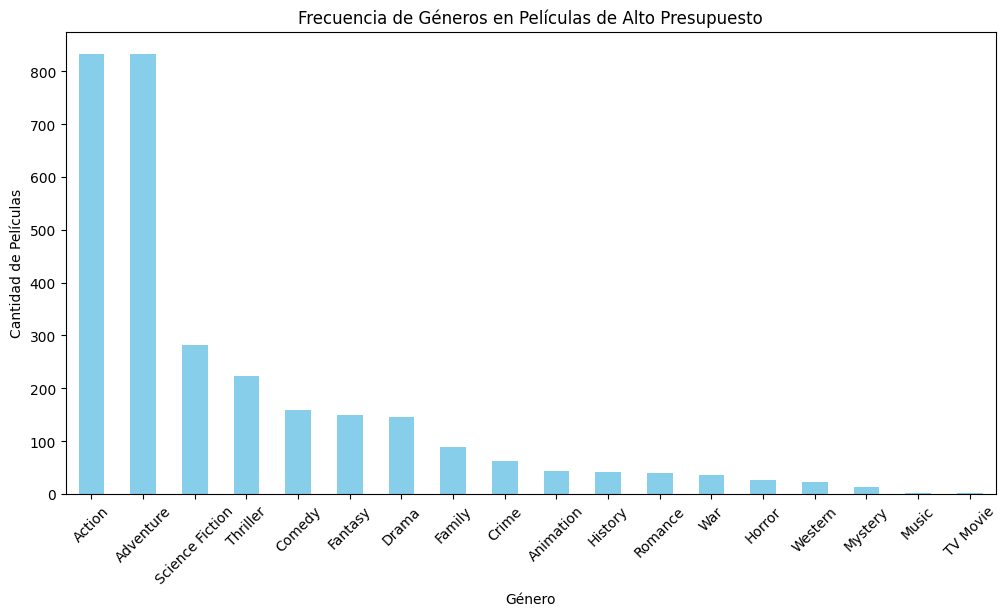

In [11]:
#Visualización de los géneros más frecuentes
plt.figure(figsize=(12, 6))
generos_conteo.plot(kind='bar', color='skyblue')
plt.title('Frecuencia de Géneros en Películas de Alto Presupuesto')
plt.xlabel('Género')
plt.ylabel('Cantidad de Películas')
plt.xticks(rotation=45)
plt.show()

Notamos que géneros como Acción y Aventura son los más frecuentes en este dataset, lo que sugiere que las inversiones más altas se concentran en producciones de entretenimiento masivo

## Analisis de presupuesto vs ingresos
Para el siguiente analisis observaremos como es el comportamiento de el ingreso de las peliculas en comparación a su presupuesto incicial, y como este puede ir variando según el incremento de este.

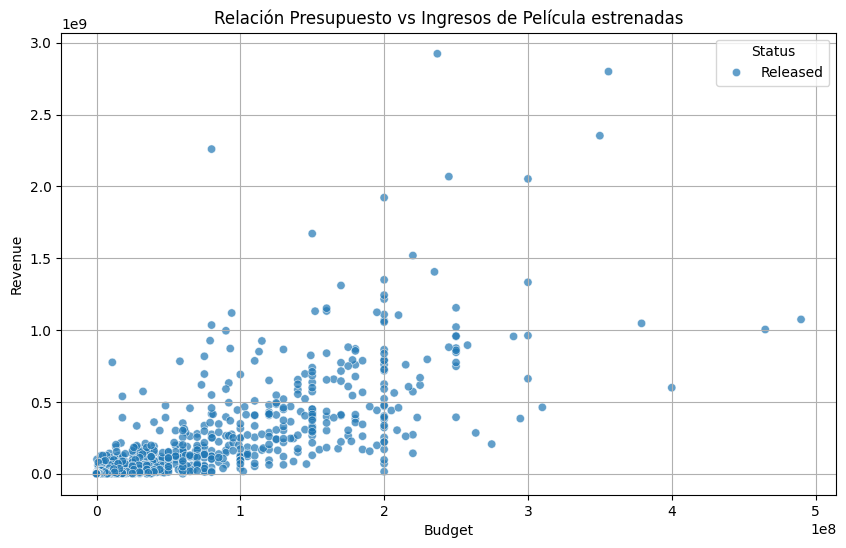

In [12]:
#Graficamos la relación entre inversión y recaudación,
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_limpio, x="Budget", y="Revenue", hue="Status", alpha=0.7)
plt.title('Relación Presupuesto vs Ingresos de Película estrenadas')
plt.grid(True)
plt.show()

El gráfico muestra una tendencia donde, a mayor presupuesto, generalmente aumentan los ingresos. Sin embargo, Existen puntos contradictorios donde no suceden esos casos de mayor beneficio.

Ahora incluiremos el año donde fueron lanzadas las peliculas y como fluctuan los presupuesto mediante el pasar del tiempo

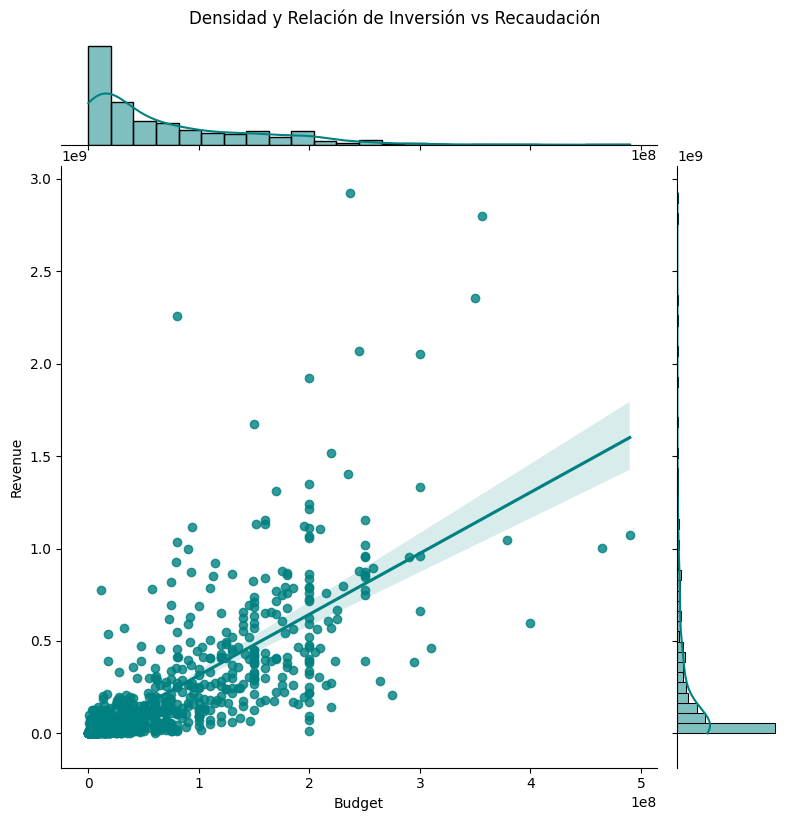

In [13]:
#Graficamos nuevamente para ver la relación Budget/Revenue y la distribución de las variables al mismo tiempo.
sns.jointplot(data=df_limpio, x="Budget", y="Revenue", kind="reg", height=8, color="teal")
plt.suptitle('Densidad y Relación de Inversión vs Recaudación', y=1.02)
plt.show()

In [14]:
#Convertimos la columna a objeto datetime y extraemos el año
#para poder agrupar los datos económicamente.
df_limpio['Release_Date'] = pd.to_datetime(df_limpio['Release_Date'])
df_limpio['Year'] = df_limpio['Release_Date'].dt.year

In [15]:
#Agrupamos por año para ver el promedio de presupuesto e ingresos
tendencia_anual = df_limpio.groupby('Year')[['Budget', 'Revenue']].mean().reset_index()

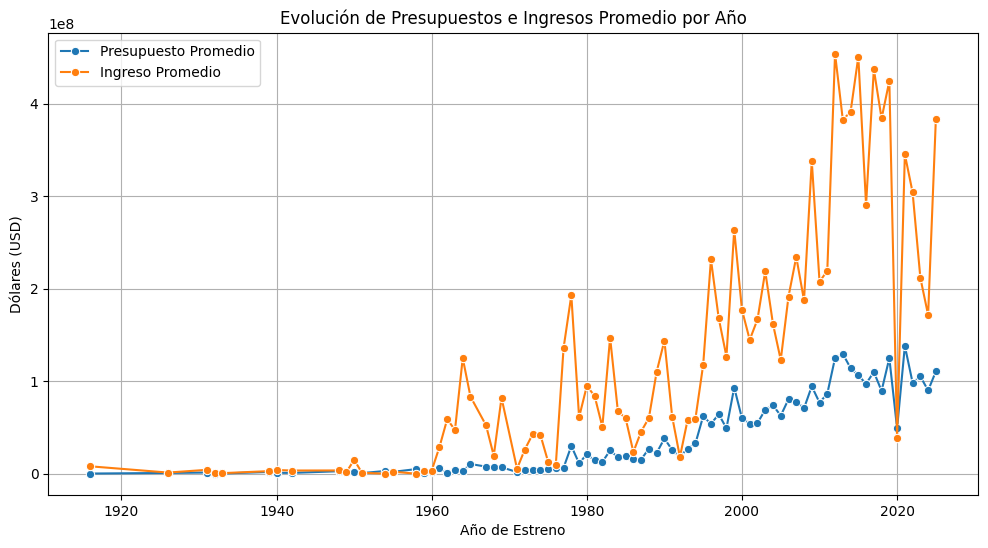

In [16]:
#Visualización de la evolución
plt.figure(figsize=(12, 6))
sns.lineplot(data=tendencia_anual, x='Year', y='Budget', label='Presupuesto Promedio', marker='o')
sns.lineplot(data=tendencia_anual, x='Year', y='Revenue', label='Ingreso Promedio', marker='o')
plt.title('Evolución de Presupuestos e Ingresos Promedio por Año')
plt.ylabel('Dólares (USD)')
plt.xlabel('Año de Estreno')
plt.grid(True)
plt.legend()
plt.show()

Podemos ver un crecimiento en el Budget promedio por año que tienen las peliculas y las ganancias que presentan estas según la epoca.

No basta con ver cuánto dinero entró en total, lo que realmente cuenta para el negocio es cuánto queda de ganancia real después de los gastos. Por eso, para nuestro análisis calculamos el Profit restando lo que costó hacer la película de lo que recaudó en cines. Esto es clave porque nos permite encontrar cuáles películas fueron un buen negocio y cuáles terminaron en pérdida, sin importar si fueron muy famosas o populares


##Analisis sobre la cantidad de ganancias

In [17]:
#Calculamos el Profit
#Justificación: Creamos la columna Profit para cuantificar el retorno económico real.
df_limpio['Profit'] = df_limpio['Revenue'] - df_limpio['Budget']

In [18]:
#Obtener las 10 películas con más profit
top_10_profit = df_limpio.nlargest(10, 'Profit')[['Title', 'Budget', 'Revenue', 'Profit']]

In [19]:
#Mostramos las tablas de resultados
display(top_10_profit)

,Title,Budget,Revenue,Profit
13,Avatar,237000000,2923706026,2686706026
28,Avengers: Endgame,356000000,2799439100,2443439100
23,Ne Zha 2,80000000,2259822417,2179822417
20,Avatar: The Way of Water,350000000,2353096253,2003096253
102,Star Wars: The Force Awakens,245000000,2068223624,1823223624
9,Avengers: Infinity War,300000000,2052415039,1752415039
8,Spider-Man: No Way Home,200000000,1921847111,1721847111
104,Jurassic World,150000000,1671537444,1521537444
5,The Avengers,220000000,1518815515,1298815515
41,Avengers: Age of Ultron,235000000,1405403694,1170403694


In [20]:
#Obtener las 10 películas con menos profit (mayores pérdidas)
bottom_10_profit = df_limpio.nsmallest(10, 'Profit')[['Title', 'Budget', 'Revenue', 'Profit']]

In [21]:
display(bottom_10_profit)


,Title,Budget,Revenue,Profit
67,The Tomorrow War,200000000,14400000,-185600000
169,Mulan,200000000,69965374,-130034626
372,Argylle,200000000,96221061,-103778939
871,Cutthroat Island,102000000,16000000,-86000000
272,Moonfall,146000000,67319703,-78680297
12,TRON: Ares,220000000,142249983,-77750017
178,The Marvels,274800000,206136825,-68663175
1347,A Sound of Thunder,80000000,11700000,-68300000
100,Kraven the Hunter,130000000,62076533,-67923467
490,Zoom,75600000,12506188,-63093812


Podemos observar que películas como 'Avatar' lideran el ranking con ganancias que superan los 2.6 billones de dólares, mientras que en el grupo de menores beneficios encontramos producciones cuyos ingresos no lograron cubrir la inversión inicial del Budget

Para visualizar la brecha financiera, crearemos un gráfico de barras horizontal consolidado. Utilizaremos colores diferenciados (verde para ganancias y rojo para pérdidas) para facilitar la interpretación visual de la salud económica de estas producciones de alto perfil.

In [22]:
#Combinamos ambos grupos para el gráfico
extremos = pd.concat([top_10_profit, bottom_10_profit]).sort_values('Profit', ascending=False)

/tmp/ipykernel_13484/2446270420.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=extremos, x='Profit', y='Title', palette=colors)


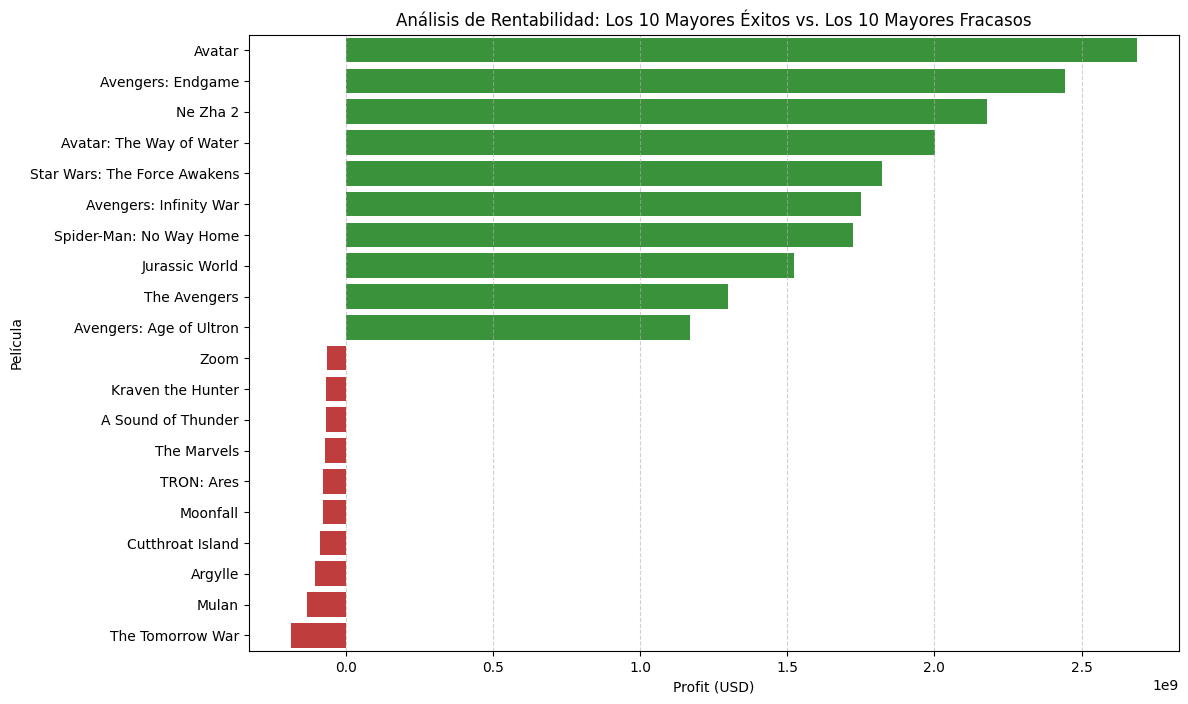

In [23]:
plt.figure(figsize=(12, 8))
# Asignamos colores: verde para profit positivo, rojo para negativo
colors = ['#2ca02c' if x > 0 else '#d62728' for x in extremos['Profit']]

sns.barplot(data=extremos, x='Profit', y='Title', palette=colors)
plt.title('Análisis de Rentabilidad: Los 10 Mayores Éxitos vs. Los 10 Mayores Fracasos')
plt.xlabel('Profit (USD)')
plt.ylabel('Película')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [24]:
df.describe()

,ID,Popularity,Vote_Average,Vote_Count,Runtime,Budget,Revenue
count,8.121000e+03,8121.000000,8121.000000,8121.000000,8121.000000,8.121000e+03,8.121000e+03
mean,5.377308e+05,1.220255,4.130074,469.181505,78.123507,7.941100e+06,2.340326e+07
std,4.888729e+05,2.891697,2.992888,2314.023411,50.077687,3.293861e+07,1.285246e+08
min,1.100000e+01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,1.030480e+05,0.226700,0.000000,0.000000,51.000000,0.000000e+00,0.000000e+00
50%,3.995660e+05,0.528300,5.000000,3.000000,88.000000,0.000000e+00,0.000000e+00
75%,8.784140e+05,1.152300,6.380000,33.000000,101.000000,0.000000e+00,0.000000e+00
max,1.655003e+06,81.596700,10.000000,38855.000000,999.000000,4.899000e+08,2.923706e+09


##Preparación de Encoders


In [25]:
#Instalamos la librería necesaria
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.8 MB/s eta 0:00:00


In [26]:
import category_encoders as ce

In [27]:
# Justificación: Aplicamos One-Hot Encoding a la columna 'Status' esto creará columnas como Status_Released, Status_Post-Production, etc.
encoder = ce.OneHotEncoder(cols=['Status'], use_cat_names=True)
df_encoded = encoder.fit_transform(df_limpio)

In [28]:
# Visualizamos el cambio
print("Nuevas columnas generadas por el encoder:")
df_encoded.filter(like='Status').head()

Nuevas columnas generadas por el encoder:


,Status_Released
1,1
2,1
3,1
4,1
5,1


Ahora la columna 'Status' se ha dividido en varias columnas numéricas. Si una película tiene un 1 en 'Status_Released', significa que ya fue estrenada. Esto permitirá que nuestro futuro modelo de regresión entienda el estado de la película como una variable de entrada

Si en el futuro deseamos predecir, por ejemplo, el idioma principal de una película exitosa, podemos usar un Label Encoder. Este asigna un número entero a cada etiqueta, simplificando la estructura para el algoritmo

##Analisis de Lenguaje y Ganancias

In [29]:
#Importamos LabelEncoder para convertir categorias
from sklearn.preprocessing import LabelEncoder

In [30]:
#Convertimos los códigos de idioma en etiquetas numéricas
le = LabelEncoder()
df_encoded['Language_Code'] = le.fit_transform(df_encoded['Original_Language'])

In [31]:
#Mostramos el mapeo realizado
print("Mapeo de Idiomas a Números:")
for i, lang in enumerate(le.classes_):
    print(f"{lang} -> {i}")

Mapeo de Idiomas a Números:
cn -> 0
de -> 1
en -> 2
es -> 3
fr -> 4
hi -> 5
id -> 6
it -> 7
ja -> 8
kn -> 9
ko -> 10
lv -> 11
ml -> 12
ms -> 13
no -> 14
pa -> 15
ru -> 16
ta -> 17
te -> 18
th -> 19
tr -> 20
uk -> 21
ur -> 22
zh -> 23


In [32]:
#Agrupamos por el nuevo código numérico de idioma para calcular el profit promedio y ver qué mercados son más rentables matemáticamente.
analisis_idioma = df_encoded.groupby(['Original_Language', 'Language_Code'])['Profit'].mean().reset_index()
analisis_idioma = analisis_idioma.sort_values(ascending=False, by='Profit')

/tmp/ipykernel_13484/1289997984.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analisis_idioma.head(10), x='Profit', y='Original_Language', palette='cool')


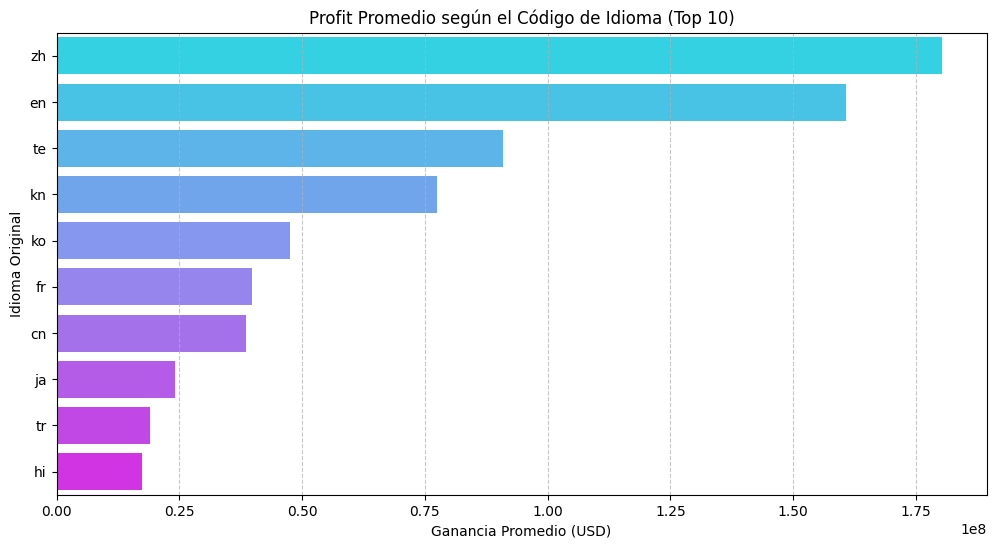

In [33]:
#Graficamos
plt.figure(figsize=(12, 6))
sns.barplot(data=analisis_idioma.head(10), x='Profit', y='Original_Language', palette='cool')
plt.title('Profit Promedio según el Código de Idioma (Top 10)')
plt.xlabel('Ganancia Promedio (USD)')
plt.ylabel('Idioma Original')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Al convertir categorías en columnas binarias, podemos integrarlas en la matriz de correlación para cuantificar el impacto de factores cualitativos en el rendimiento financiero

##Analisis de correlación sobre Ganancias

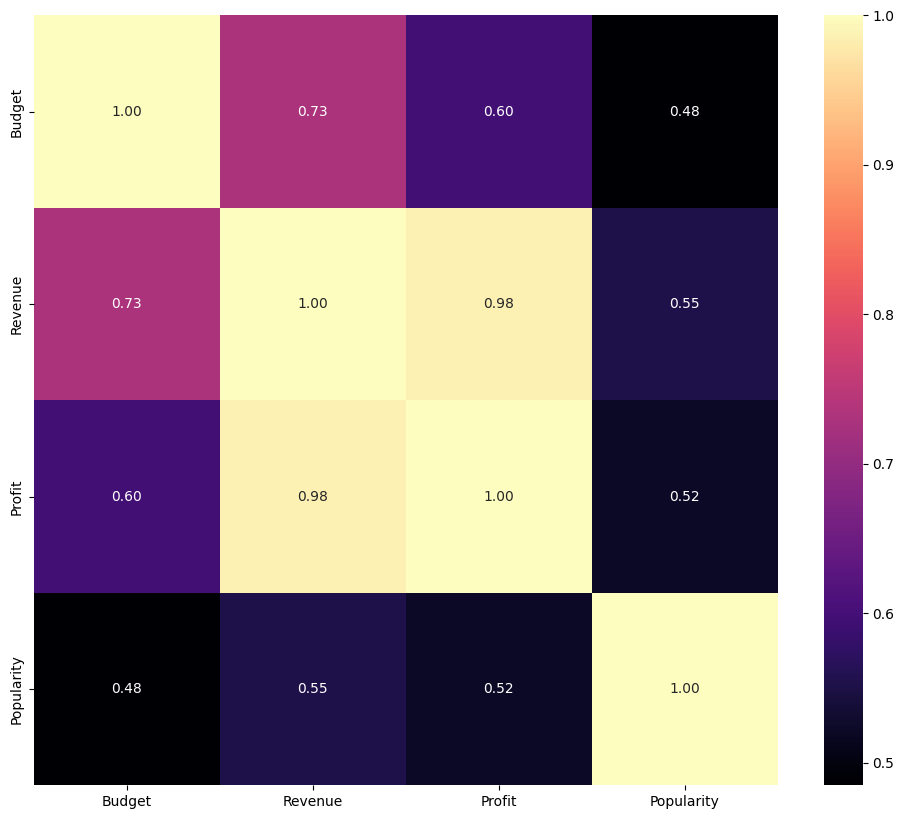

In [34]:
#Grafico de impacto en el Profit.
columnas_modelo = ['Budget', 'Revenue', 'Profit', 'Popularity']
corr_matrix_ext = df_encoded[columnas_modelo].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_ext, annot=True, cmap='magma', fmt=".2f")
plt.show()

Utilizaremos un algoritmo de ensamble para identificar qué variables tienen mayor peso estadístico.

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
#Creamos una variable objetivo rápida: 1 si profit > 0 (Éxito), 0 si no.
df_encoded['Es_Exito'] = (df_encoded['Profit'] > 0).astype(int)

In [37]:
#Definimos X (características) e y (objetivo)
X = df_encoded[['Budget', 'Popularity', 'Runtime'] + list(df_encoded.filter(like='Status').columns)]
y = df_encoded['Es_Exito']

In [38]:
#Entrenamos un modelo rápido para ver importancia
modelo_importancia = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_importancia.fit(X, y)

RandomForestClassifier(random_state=42)

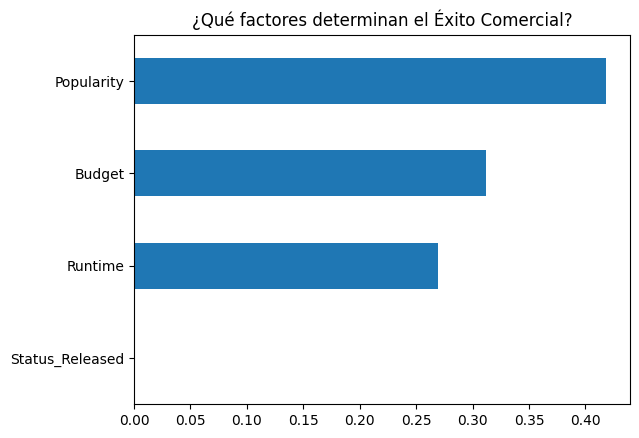

In [39]:
#Graficamos
importancias = pd.Series(modelo_importancia.feature_importances_, index=X.columns).sort_values(ascending=True)
importancias.plot(kind='barh', title='¿Qué factores determinan el Éxito Comercial?')
plt.show()

##Analisis de Popularidad y Calidad

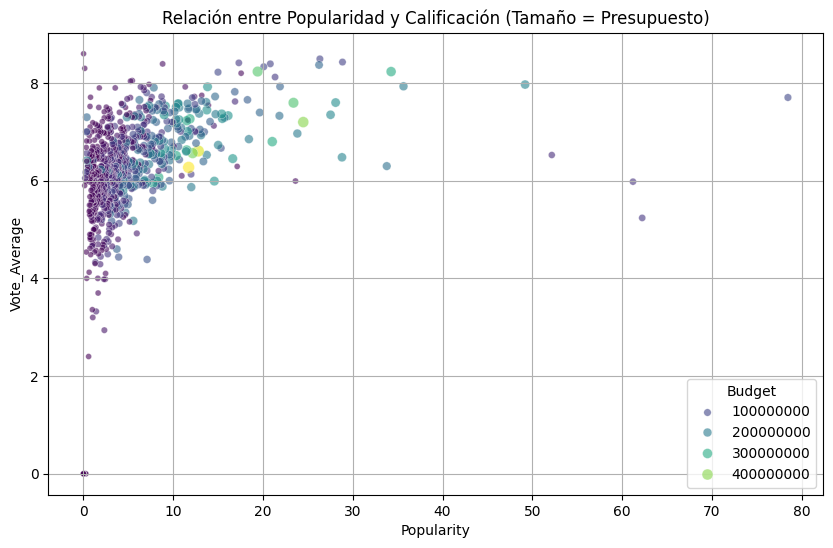

In [40]:
#Cruzamos popularidad con calificación para entender el comportamiento del público.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_limpio, x="Popularity", y="Vote_Average", hue="Budget", size="Budget", alpha=0.6, palette="viridis")
plt.title('Relación entre Popularidad y Calificación (Tamaño = Presupuesto)')
plt.grid(True)
plt.show()

git config --global user.email vi.vilchesm@duocuc.cl
git config --global user.name vivilchesm-rgb